# Predict tides with aviso pyfes
**Kernel**  
- Run with kernel *aviso-fes*
- conda does not work together with a venv environment
02.06.2025  
- Installed Miniforge: https://github.com/conda-forge/miniforge (page also contains instructions to uninstall)  
- New environment: ```conda create -n aviso-fes```  
- Activate environment: ```conda activate aviso-fes```  
- Install package: ```conda install -c conda-forge pyfes```  
- Deactivate environment: ```conda deactivate```  
- Make a kernel: ```conda install ipykernel, ``` ```ipython kernel install --user --name=aviso-fes```  
Output: ```Installed kernelspec aviso-fes in /home/bene/.local/share/jupyter/kernels/aviso-fes```  

**Data**  
Requires EOT20 data, download here: https://doi.org/10.17882/79489  

**Define constituents**  
.yaml-file template: https://github.com/CNES/aviso-fes/blob/main/examples/fes_slev.yml  
The .yaml-file used in this notebook is provided in the input folder to the respective data folder.  

## Imports

In [1]:
import pyfes
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

## Paths

In [2]:
# datapaths to the tide model
path_eot = '/media/bene/Seagate/PhD-data/3_ocean_tide_models/EOT20/'
os.environ['DATASET_DIR'] = path_eot

path_input = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/01_tides/input/'
path_output = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/01_tides/output/'

## Function

In [3]:
def predict_tides(handlers, dates, lon, lat):
    lons = np.full(dates.shape, lon)
    lats = np.full(dates.shape, lat)
    
    ocean_tide, ocean_lp, _ = pyfes.evaluate_tide(handlers['tide'],
                                  dates,
                                  lons,
                                  lats,
                                  num_threads=1)
    load_tide, load_lp, _ = pyfes.evaluate_tide(handlers['radial'],
                                           dates,
                                           lons,
                                           lats,
                                           num_threads=1)
    
    # total correction (diurnal and semidiurnal + long period wave constituents for ocean and load tides)
    corr = ocean_tide + ocean_lp + load_tide + load_lp
    
    corr_df = pd.DataFrame({'dates':pd.to_datetime(dates).tz_localize('UTC'), 'corr_eot[m]':corr/100}).set_index(['dates'])

    return corr_df

## Terschelling

In [5]:
lon_ters_tg = 5.351231
lat_ters_tg = 53.420034

# For testing spatial variability
lon_ters_west = 5.1718
lat_ters_west = 53.3968

lon_ters_east = 5.51291
lat_ters_east = 53.45238

In [6]:
start_date = np.datetime64('1993-01-01')
end_date = np.datetime64('1994-01-01')
dates = np.arange(start_date, end_date, np.timedelta64(10, 'm'))

In [7]:
handlers_ters = pyfes.load_config(path_input+'eot20.yaml', bbox=(4, 52, 6, 54)) # bounding box: min lon, min lat, max lon, and max lat

In [27]:
corr_west = predict_tides(handlers_ters, dates, lon_ters_west, lat_ters_west)
corr_east = predict_tides(handlers_ters, dates, lon_ters_east, lat_ters_east)

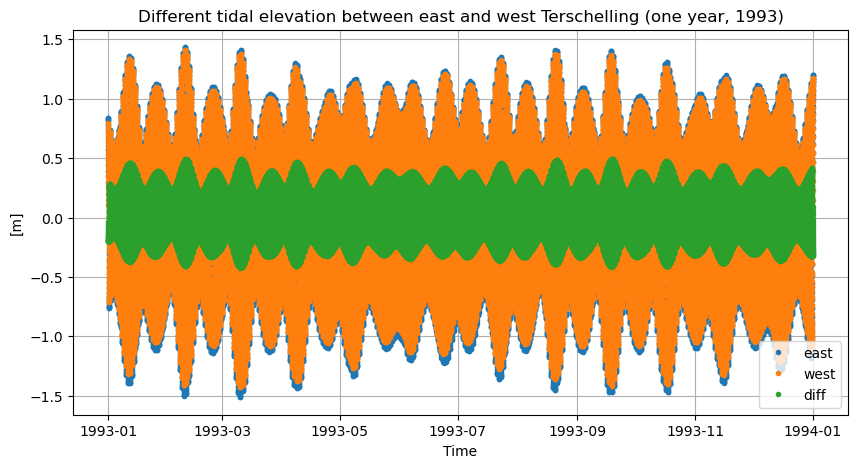

In [28]:
diff = corr_west - corr_east

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(corr_east.index, corr_east['corr_eot[m]'], '.', label='east')
ax.plot(corr_west.index, corr_west['corr_eot[m]'], '.', label='west')
ax.plot(diff.index, diff['corr_eot[m]'], '.', label='diff')

ax.set_xlabel('Time')
ax.set_ylabel('[m]')
ax.set_title('Different tidal elevation between east and west Terschelling (one year, 1993)')
ax.legend()
ax.grid()

In [8]:
start_date = np.datetime64('1993-01-01')
end_date = np.datetime64('2026-01-01')
dates = np.arange(start_date, end_date, np.timedelta64(10, 'm'))

corr_ters = predict_tides(handlers_ters, dates, lon_ters_tg, lat_ters_tg)

# corr_ters.to_csv(path_output + 'tides_ters.csv')

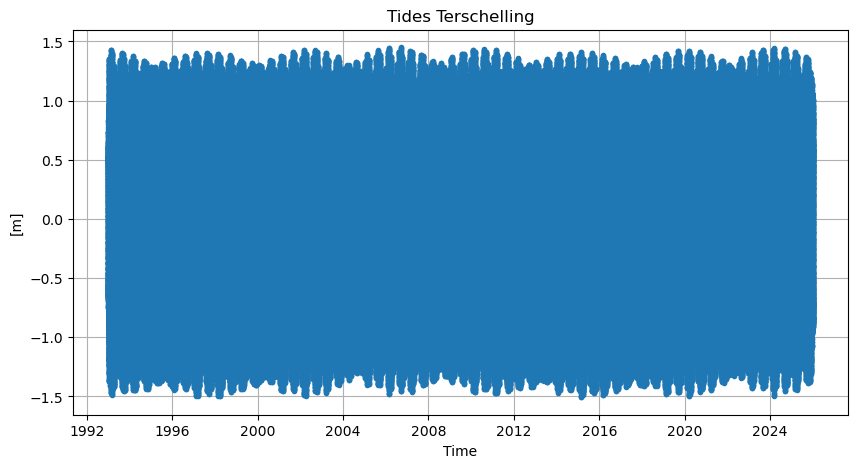

In [18]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(corr_ters.index, corr_ters['corr_eot[m]'], '.')

ax.set_xlabel('Time')
ax.set_ylabel('[m]')
ax.set_title('Tides Terschelling')
ax.grid()

### compare to old version

In [3]:
path = '/media/bene/Seagate/PhD-data/3_ocean_tide_models/'
fn = 'tidal_correction_10minutes.csv'
old_corr = pd.read_csv(path+fn, index_col='date', parse_dates=['date'])

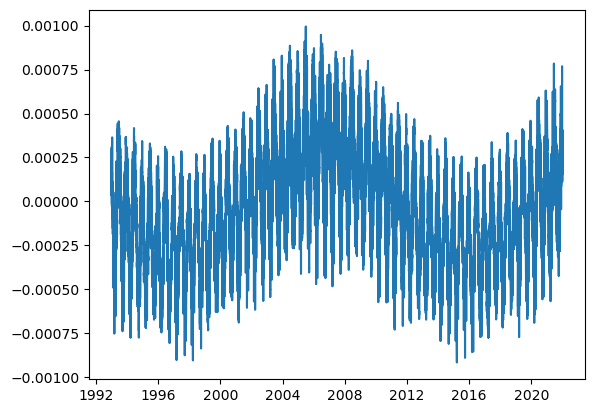

In [22]:
diff = corr_ters['corr_eot[m]'] - old_corr['corr_eot[cm]']/100

fig, ax = plt.subplots()
ax.plot(diff)

## Duck

In [4]:
lon_duck_tg = -75.747
lat_duck_tg = 36.183

In [5]:
handlers_duck = pyfes.load_config(path_input+'eot20.yaml', bbox=(-77, 35, -75, 37)) # bounding box: min lon, min lat, max lon, and max lat

In [6]:
start_date = np.datetime64('1993-01-01')
end_date = np.datetime64('2026-01-01')
dates = np.arange(start_date, end_date, np.timedelta64(10, 'm'))

corr_duck = predict_tides(handlers_duck, dates, lon_duck_tg, lat_duck_tg)

corr_duck.to_csv(path_output + 'tides_duck.csv')

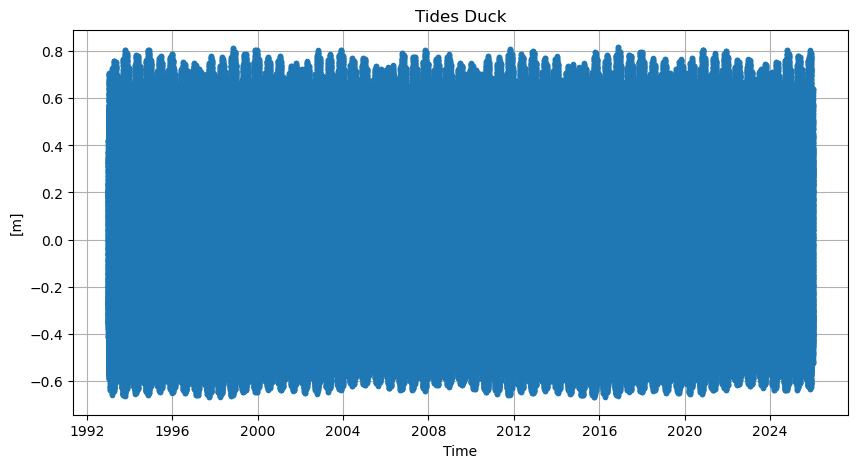

In [7]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(corr_duck.index, corr_duck['corr_eot[m]'], '.')

ax.set_xlabel('Time')
ax.set_ylabel('[m]')
ax.set_title('Tides Duck')
ax.grid()

## Narrabeen

In [4]:
# outer point of profile 4
lon_narra_tg = 151.30071
lat_narra_tg = -33.71728

In [5]:
handlers_narra = pyfes.load_config(path_input+'eot20.yaml', bbox=(150, -35, 153, -32)) # bounding box: min lon, min lat, max lon, and max lat

In [ ]:
start_date = np.datetime64('1993-01-01')
end_date = np.datetime64('2026-01-01')
dates = np.arange(start_date, end_date, np.timedelta64(10, 'm'))

corr_narra = predict_tides(handlers_narra, dates, lon_narra_tg, lat_narra_tg)

corr_narra.to_csv(path_output + 'tides_narra.csv')

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(corr_narra.index, corr_narra['corr_eot[m]'], '.')

ax.set_xlabel('Time')
ax.set_ylabel('[m]')
ax.set_title('Tides Narrabeen')
ax.grid()